# Proyecto Deep Learning — Detección de Latas de Bebidas
## Evaluación Parcial N°1 — Fundamentos de Deep Learning

**Autores:** Jonathan Araneda · Giovanni Ortiz · Diego Martinez · Nicolas Valenzuela  
**Profesor:** Cristian Garcia | **Curso:** DLY0100 | **Fecha:** 19-04-2026

---
**Objetivo:** Clasificar imágenes binarias (Latas / No Latas) mediante una MLP implementada en PyTorch.  
**Etapas:** Preprocesamiento → MLP → Funciones de activación/error/salida → Experimentos controlados → Regularización → Evaluación → Conclusiones

In [2]:
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from pathlib import Path

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"Usando  : {DEVICE}")

Python  : 3.11.0
PyTorch : 2.5.1+cu124
CUDA    : True
Usando  : cuda


In [3]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)

sns.set(style="whitegrid")
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


---
## 1. Carga y Preprocesamiento de Datos (IEE 1.1.1)

### Transformaciones aplicadas

| Transformación | Justificación |
|---|---|
| `Resize(64, 64)` | Uniformiza el tamaño; entrada MLP = 64×64×3 = 12 288 features |
| `RandomHorizontalFlip` | Aumentación: genera variaciones horizontales → mejor generalización |
| `RandomRotation(15°)` | Aumentación: simula distintos ángulos de captura |
| `ColorJitter` | Aumentación: variaciones de iluminación y color |
| `ToTensor` | PIL Image → tensor PyTorch en [0, 1] |
| `Normalize(ImageNet)` | Normaliza canales RGB; estabiliza el gradiente |

> 64×64 es un compromiso: captura patrones visuales sin generar vectores de entrada excesivamente grandes para una MLP.

In [4]:
# ── Rutas del dataset ──────────────────────────────────────────────────────
path = Path(r'C:\Users\Administrator\Desktop\Dataset')
train_path = path / 'train'
val_path   = path / 'valid'
test_path  = path / 'test'

# Verificación rápida
for nombre, ruta in [('TRAIN', train_path), ('VALID', val_path), ('TEST', test_path)]:
    print(f"{nombre}: {ruta}")
    if ruta.exists():
        for d in sorted(ruta.iterdir()):
            if d.is_dir():
                print(f"  {d.name}: {len(list(d.glob('*.*')))} imgs")
    else:
        print("  [No encontrada]")

TRAIN: C:\Users\Administrator\Desktop\Dataset\train
  Latas: 10002 imgs
  No_Latas: 26353 imgs
VALID: C:\Users\Administrator\Desktop\Dataset\valid
  Latas: 1092 imgs
  No_Latas: 2725 imgs
TEST: C:\Users\Administrator\Desktop\Dataset\test
  Latas: 455 imgs
  No_Latas: 1058 imgs


In [5]:
# ── Parámetros globales ─────────────────────────────────────────────────────
IMG_SIZE   = 64
BATCH_SIZE = 64
MEAN, STD  = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

# Transformación entrenamiento: con aumentación
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Transformación validación/test: solo resize + normalización
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

print(f"Entrada MLP: {IMG_SIZE}x{IMG_SIZE}x3 = {IMG_SIZE*IMG_SIZE*3} features")

Entrada MLP: 64x64x3 = 12288 features


In [5]:
# ── Datasets y DataLoaders ──────────────────────────────────────────────────
train_dataset = datasets.ImageFolder(str(train_path), transform=train_transforms)
val_dataset   = datasets.ImageFolder(str(val_path),   transform=val_transforms)
test_dataset  = datasets.ImageFolder(str(test_path),  transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

clases = train_dataset.classes
print(f"Clases: {clases}")
print(f"Train: {len(train_dataset)} | Valid: {len(val_dataset)} | Test: {len(test_dataset)}")

conteo = Counter([l for _, l in train_dataset.samples])
for i, c in enumerate(clases):
    print(f"  {c}: {conteo[i]} imágenes")

Clases: ['Latas', 'No_Latas']
Train: 36355 | Valid: 3815 | Test: 1513
  Latas: 10002 imágenes
  No_Latas: 26353 imágenes


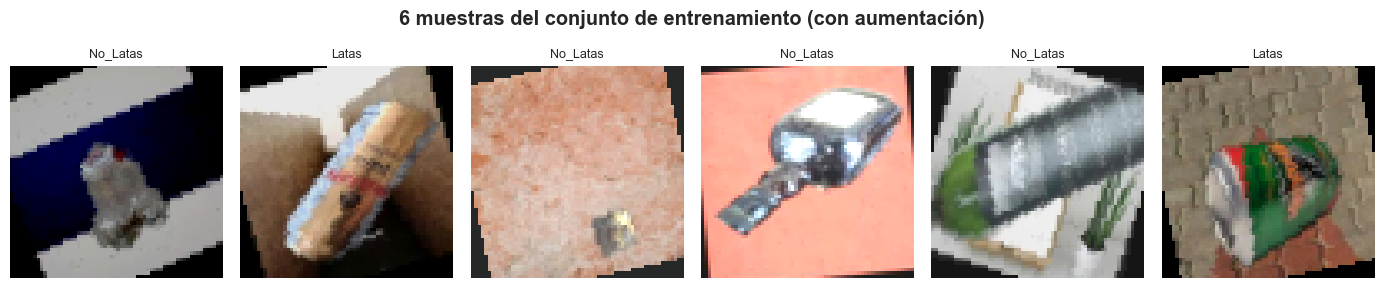

In [6]:
# ── Visualización de 6 muestras ─────────────────────────────────────────────
def desnorm(t):
    t = t.clone()
    for c, m, s in zip(range(3), MEAN, STD):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for i, ax in enumerate(axes):
    img = desnorm(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(clases[labels[i].item()], fontsize=9)
    ax.axis('off')
plt.suptitle("6 muestras del conjunto de entrenamiento (con aumentación)", fontweight='bold')
plt.tight_layout(); plt.show()

---
## 2. Configuración de Parámetros Clave (IEE 1.1.2)

Los parámetros base usados en todos los experimentos (salvo el que se varía):

In [6]:
# ── Hiperparámetros clave ────────────────────────────────────────────────────
EPOCHS_BASE  = 20      # épocas de entrenamiento base
LR_BASE      = 1e-3    # learning rate base 
BS_BASE      = 64      
INPUT_SIZE   = IMG_SIZE * IMG_SIZE * 3   # 12 288
HIDDEN_SIZES  = [1024, 512, 256]
DROPOUT_RATES = [0.5, 0.4, 0.3]
NUM_CLASSES   = 2

print(f"Épocas    : {EPOCHS_BASE}")
print(f"LR        : {LR_BASE}")
print(f"Batch size: {BS_BASE}")
print(f"Input size: {INPUT_SIZE}")
print(f"Arquitectura: {INPUT_SIZE} → {' → '.join(map(str, HIDDEN_SIZES))} → {NUM_CLASSES}")

Épocas    : 20
LR        : 0.001
Batch size: 64
Input size: 12288
Arquitectura: 12288 → 1024 → 512 → 256 → 2


---
## 3. Implementación de la MLP en PyTorch (IEE 1.3.1)

Arquitectura: **3 capas ocultas** (1024 → 512 → 256) + capa de salida (2 clases).  
Cada capa oculta incluye: `Linear → BatchNorm → Activación → Dropout` (configurable).

| Componente | Justificación |
|---|---|
| 3 capas ocultas | Capacidad suficiente para patrones no lineales binarios |
| BatchNorm | Estabiliza y acelera el entrenamiento |
| Dropout | Regularización: reduce sobreajuste |
| ReLU (por defecto) | Evita gradiente que desaparece; estándar en MLPs |
| Softmax (implícito) | CrossEntropyLoss lo aplica internamente |

In [10]:
class MLP(nn.Module):
    """
    Multilayer Perceptron configurable para clasificación de imágenes.
    
    Parámetros:
      input_size   : dimensión del vector de entrada
      hidden_sizes : lista con neuronas de cada capa oculta
      num_classes  : clases de salida
      dropout_rates: lista de tasas de dropout por capa
      activation   : 'relu' | 'leaky_relu' | 'tanh'
      use_batchnorm: añadir BatchNorm tras cada capa lineal
    """
    def __init__(self, input_size, hidden_sizes, num_classes=2,
                 dropout_rates=None, activation='relu', use_batchnorm=True):
        super().__init__()
        if dropout_rates is None:
            dropout_rates = [0.5] * len(hidden_sizes)

        act_map = {
            'relu':       nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(negative_slope=0.1),
            'tanh':       nn.Tanh(),
        }
        if activation not in act_map:
            raise ValueError(f"Activación '{activation}' no reconocida. Opciones: {list(act_map)}")

        layers, prev = [], input_size
        for h, dr in zip(hidden_sizes, dropout_rates):
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_map[activation])
            layers.append(nn.Dropout(p=dr))
            prev = h
        layers.append(nn.Linear(prev, num_classes))  # capa de salida (sin activación)
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # aplanar imagen → vector
        return self.network(x)       # retorna logits

# Instanciar modelo base y mostrar arquitectura
modelo = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES, DROPOUT_RATES,
             activation='relu', use_batchnorm=True).to(DEVICE)
print(modelo)
total  = sum(p.numel() for p in modelo.parameters())
entren = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"\nParámetros totales    : {total:,}")
print(f"Parámetros entrenables: {entren:,}")

MLP(
  (network): Sequential(
    (0): Linear(in_features=12288, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=2, bias=True)
  )
)

Parámetros totales    : 13,244,162
Parámetros entrenables: 13,244,162


---
## 4. Funciones de Activación, Error y Salida (IEE 1.2.1 · 1.2.2 · 1.2.3)

### 4.1 Funciones de Activación — Visualización de 3 funciones

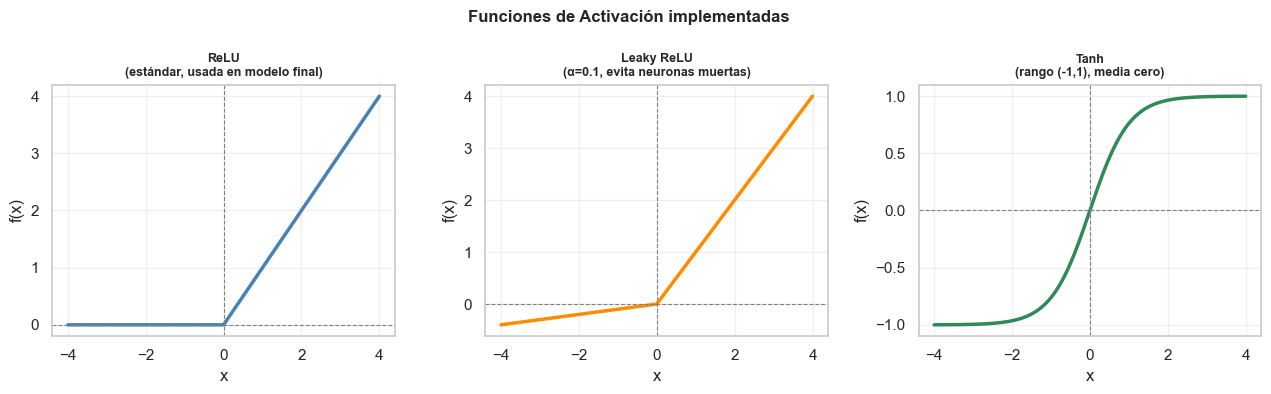

In [ ]:
x = np.linspace(-4, 4, 400)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
funciones = [
    ('ReLU\n(estándar, usada en modelo final)', np.maximum(0, x),           'steelblue'),
    ('Leaky ReLU\n(α=0.1, evita neuronas muertas)', np.where(x>=0, x, 0.1*x), 'darkorange'),
    ('Tanh\n(rango (-1,1), media cero)',            np.tanh(x),               'seagreen'),
]
for ax, (nombre, y, color) in zip(axes, funciones):
    ax.plot(x, y, color=color, linewidth=2.5)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_title(nombre, fontsize=9, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.grid(alpha=0.3)

plt.suptitle('Funciones de Activación implementadas', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Tabla comparativa de funciones de activación:**

| Función | Rango | Ventaja | Desventaja |
|---|---|---|---|
| **ReLU** | [0, +∞) | Simple, eficiente, sin gradiente saturado para x>0 | Neuronas muertas (x<0 → grad=0) |
| **Leaky ReLU** | (-∞, +∞) | Resuelve neuronas muertas con pendiente α para x<0 | Hiperparámetro α adicional |
| **Tanh** | (-1, 1) | Media cero → convergencia más rápida que Sigmoid | Saturación en valores extremos |

**Elección:** `ReLU` — es la estándar de la industria, computacionalmente eficiente y funciona bien con BatchNorm.

### 4.2 Función de Error — CrossEntropyLoss vs LabelSmoothing

In [ ]:
# Verificación con PyTorch
logits_ok  = torch.tensor([[0.5, 2.5]])
logits_mal = torch.tensor([[2.5, 0.5]])
target     = torch.tensor([1])

ce = nn.CrossEntropyLoss()
print("=== CrossEntropyLoss (PyTorch) ===")
print(f"  Pred. correcta  (logit clase1=2.5): Loss = {ce(logits_ok, target).item():.4f}")
print(f"  Pred. incorrecta(logit clase0=2.5): Loss = {ce(logits_mal, target).item():.4f}")

print("\nFunciones de error utilizadas:")
print("  • CrossEntropyLoss : combina LogSoftmax + NLLLoss; estándar para clasificación multi-clase")
print("  • LabelSmoothing   : suaviza las etiquetas one-hot; reduce sobreconfianza del modelo")
print("\nElección: CrossEntropyLoss → función estándar, bien calibrada para clasificación binaria.")

=== CrossEntropyLoss (PyTorch) ===
  Pred. correcta  (logit clase1=2.5): Loss = 0.1269
  Pred. incorrecta(logit clase0=2.5): Loss = 2.1269

Funciones de error utilizadas:
  • CrossEntropyLoss : combina LogSoftmax + NLLLoss; estándar para clasificación multi-clase
  • LabelSmoothing   : suaviza las etiquetas one-hot; reduce sobreconfianza del modelo

Elección: CrossEntropyLoss → función estándar, bien calibrada para clasificación binaria.


### 4.3 Función de Salida — Softmax

**Softmax** convierte los logits de la última capa en una distribución de probabilidad:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

- La salida suma 1.0 → interpretable como **probabilidad de clase**.
- Para `CrossEntropyLoss` de PyTorch el Softmax se aplica **internamente**, por lo que la capa de salida retorna logits crudos.

In [ ]:
# Demostración numérica de Softmax
logits_ej = np.array([2.1, -0.5])
e = np.exp(logits_ej - logits_ej.max())
probs = e / e.sum()
print("=== Función de Salida: Softmax ===")
print(f"  Logits     : {logits_ej}")
print(f"  Softmax    : {np.round(probs, 4)}")
print(f"  Suma probs : {probs.sum():.6f}  (debe ser 1.0)")
print(f"  Clase pred : índice {np.argmax(probs)}")

=== Función de Salida: Softmax ===
  Logits     : [ 2.1 -0.5]
  Softmax    : [0.9309 0.0691]
  Suma probs : 1.000000  (debe ser 1.0)
  Clase pred : índice 0


---
## 5. Funciones de Entrenamiento y Evaluación

In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds       = logits.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)
            all_preds.append(preds.cpu()); all_labels.append(labels.cpu())
    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return total_loss / total, correct / total, all_preds, all_labels


def calcular_metricas(labels, preds, verbose=True):
    acc = accuracy_score(labels, preds)
    pre = precision_score(labels, preds, average='binary', zero_division=0)
    rec = recall_score(labels, preds, average='binary', zero_division=0)
    f1  = f1_score(labels, preds, average='binary', zero_division=0)
    if verbose:
        print(f"  Accuracy : {acc:.4f}")
        print(f"  Precision: {pre:.4f}")
        print(f"  Recall   : {rec:.4f}")
        print(f"  F1-Score : {f1:.4f}")
    return {'Accuracy': acc, 'Precision': pre, 'Recall': rec, 'F1-Score': f1}


def entrenar_modelo(model, train_ldr, val_ldr, criterion, optimizer,
                    scheduler=None, epochs=15, device=DEVICE, nombre=''):
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    print(f"\n{'='*50}\n  {nombre}  |  Épocas: {epochs}\n{'='*50}")
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_ldr, criterion, optimizer, device)
        vl_loss, vl_acc, _, _ = eval_epoch(model, val_ldr, criterion, device)
        if scheduler: scheduler.step()
        hist['train_loss'].append(tr_loss); hist['val_loss'].append(vl_loss)
        hist['train_acc'].append(tr_acc);  hist['val_acc'].append(vl_acc)
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Época {epoch:3d} | TrLoss={tr_loss:.4f} TrAcc={tr_acc:.4f} | "
                  f"VlLoss={vl_loss:.4f} VlAcc={vl_acc:.4f}")
    return hist


# Función para graficar solo val_loss (experimentos de hiperparámetros)
def plot_val_loss(hists_dict, titulo, xlabel_label='Épocas'):
    fig, ax = plt.subplots(figsize=(8, 4))
    colores = ['steelblue', 'darkorange', 'seagreen']
    for (lbl, hist), color in zip(hists_dict.items(), colores):
        ax.plot(range(1, len(hist['val_loss'])+1), hist['val_loss'],
                label=str(lbl), color=color, linewidth=2)
    ax.set_xlabel(xlabel_label); ax.set_ylabel('Val Loss')
    ax.set_title(titulo, fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

print("Funciones de entrenamiento definidas.")

Funciones de entrenamiento definidas.


---
## 6. Experimentos Controlados — Un Parámetro a la Vez (IEE 1.1.3)

> **Metodología:** En cada experimento se varía **un solo parámetro**, manteniendo el resto constante en sus valores base (epochs=20, LR=1e-3, BS=32).

### 6.1 Variación del Número de Épocas

In [ ]:
criterio_base = nn.CrossEntropyLoss()
resultados_ep, hist_ep = [], {}

for epocas in [10, 20, 30]:
    m = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES, DROPOUT_RATES,
            activation='relu', use_batchnorm=True).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=LR_BASE, weight_decay=1e-4)
    sch = optim.lr_scheduler.StepLR(opt, step_size=7, gamma=0.5)
    h = entrenar_modelo(m, train_loader, val_loader, criterio_base,
                        opt, sch, epochs=epocas, device=DEVICE, nombre=f'Épocas={epocas}')
    _, _, preds, labels = eval_epoch(m, val_loader, criterio_base, DEVICE)
    met = calcular_metricas(labels, preds, verbose=False)
    met.update({'Épocas': epocas, 'Val Loss Final': round(h['val_loss'][-1], 4)})
    resultados_ep.append(met); hist_ep[epocas] = h

df_ep = pd.DataFrame(resultados_ep).set_index('Épocas')
print("\n--- Tabla: Número de Épocas ---")
print(df_ep.round(4).to_string())


  Épocas=10  |  Épocas: 10
  Época   1 | TrLoss=0.5872 TrAcc=0.7227 | VlLoss=0.5602 VlAcc=0.7337
  Época   5 | TrLoss=0.5613 TrAcc=0.7350 | VlLoss=0.5441 VlAcc=0.7408
  Época  10 | TrLoss=0.5468 TrAcc=0.7436 | VlLoss=0.5213 VlAcc=0.7562

  Épocas=20  |  Épocas: 20
  Época   1 | TrLoss=0.5879 TrAcc=0.7237 | VlLoss=0.5621 VlAcc=0.7423
  Época   5 | TrLoss=0.5616 TrAcc=0.7355 | VlLoss=0.5397 VlAcc=0.7518
  Época  10 | TrLoss=0.5470 TrAcc=0.7433 | VlLoss=0.5151 VlAcc=0.7678
  Época  15 | TrLoss=0.5355 TrAcc=0.7490 | VlLoss=0.5020 VlAcc=0.7751
  Época  20 | TrLoss=0.5269 TrAcc=0.7537 | VlLoss=0.4983 VlAcc=0.7772

  Épocas=30  |  Épocas: 30
  Época   1 | TrLoss=0.5890 TrAcc=0.7233 | VlLoss=0.5771 VlAcc=0.7321
  Época   5 | TrLoss=0.5627 TrAcc=0.7354 | VlLoss=0.5380 VlAcc=0.7633
  Época  10 | TrLoss=0.5451 TrAcc=0.7430 | VlLoss=0.5191 VlAcc=0.7588
  Época  15 | TrLoss=0.5340 TrAcc=0.7494 | VlLoss=0.5032 VlAcc=0.7746
  Época  20 | TrLoss=0.5256 TrAcc=0.7534 | VlLoss=0.4951 VlAcc=0.7782
  Époc

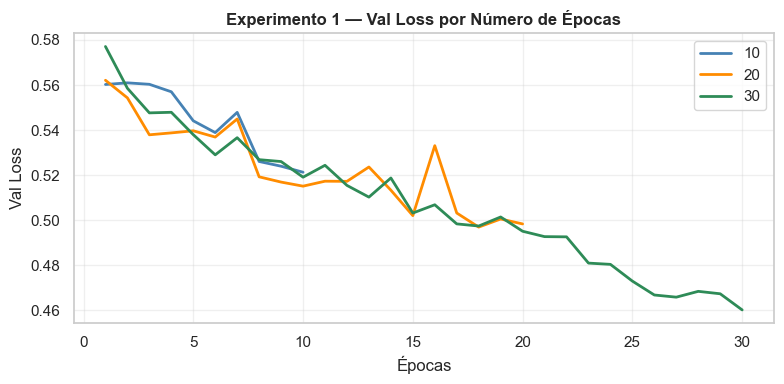

In [ ]:
plot_val_loss(hist_ep, 'Experimento 1 — Val Loss por Número de Épocas')

**Análisis:** Con 10 épocas el modelo aún no ha convergido completamente (val_loss=0.52, val_acc=0.756).
Con 20 épocas mejora notablemente (val_loss=0.498, val_acc=0.777).
Con 30 épocas se obtiene el mejor rendimiento (val_loss=0.460, val_acc=0.801), sin evidencia de sobreajuste (val_loss sigue disminuyendo).
Sin embargo, para equilibrar tiempo de cómputo y rendimiento, se eligen 20 épocas como valor óptimo, ya que el incremento de 20 a 30 épocas es modesto (+2.4% en accuracy) y no justifica el 50% más de tiempo de entrenamiento en este contexto académico.

### 6.2 Variación del Learning Rate

In [ ]:
resultados_lr, hist_lr = [], {}

for lr in [1e-4, 1e-3, 1e-2]:
    m = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES, DROPOUT_RATES,
            activation='relu', use_batchnorm=True).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)
    sch = optim.lr_scheduler.StepLR(opt, step_size=7, gamma=0.5)
    h = entrenar_modelo(m, train_loader, val_loader, criterio_base,
                        opt, sch, epochs=EPOCHS_BASE, device=DEVICE, nombre=f'LR={lr:.0e}')
    _, _, preds, labels = eval_epoch(m, val_loader, criterio_base, DEVICE)
    met = calcular_metricas(labels, preds, verbose=False)
    met.update({'LR': lr, 'Val Loss Final': round(h['val_loss'][-1], 4)})
    resultados_lr.append(met); hist_lr[f'{lr:.0e}'] = h

df_lr = pd.DataFrame(resultados_lr).set_index('LR')
print("\n--- Tabla: Learning Rate ---")
print(df_lr.round(4).to_string())


  LR=1e-04  |  Épocas: 20
  Época   1 | TrLoss=0.5976 TrAcc=0.7108 | VlLoss=0.5468 VlAcc=0.7460
  Época   5 | TrLoss=0.5362 TrAcc=0.7480 | VlLoss=0.5111 VlAcc=0.7662
  Época  10 | TrLoss=0.5056 TrAcc=0.7647 | VlLoss=0.4856 VlAcc=0.7714
  Época  15 | TrLoss=0.4817 TrAcc=0.7778 | VlLoss=0.4617 VlAcc=0.7895
  Época  20 | TrLoss=0.4652 TrAcc=0.7870 | VlLoss=0.4483 VlAcc=0.7906

  LR=1e-03  |  Épocas: 20
  Época   1 | TrLoss=0.5890 TrAcc=0.7235 | VlLoss=0.5487 VlAcc=0.7547
  Época   5 | TrLoss=0.5626 TrAcc=0.7340 | VlLoss=0.5542 VlAcc=0.7444
  Época  10 | TrLoss=0.5475 TrAcc=0.7415 | VlLoss=0.5208 VlAcc=0.7670
  Época  15 | TrLoss=0.5364 TrAcc=0.7463 | VlLoss=0.5020 VlAcc=0.7730
  Época  20 | TrLoss=0.5278 TrAcc=0.7519 | VlLoss=0.4987 VlAcc=0.7748

  LR=1e-02  |  Épocas: 20
  Época   1 | TrLoss=0.6016 TrAcc=0.7189 | VlLoss=0.5928 VlAcc=0.7138
  Época   5 | TrLoss=0.5888 TrAcc=0.7249 | VlLoss=0.5988 VlAcc=0.7138
  Época  10 | TrLoss=0.5889 TrAcc=0.7248 | VlLoss=0.5991 VlAcc=0.7138
  Época  

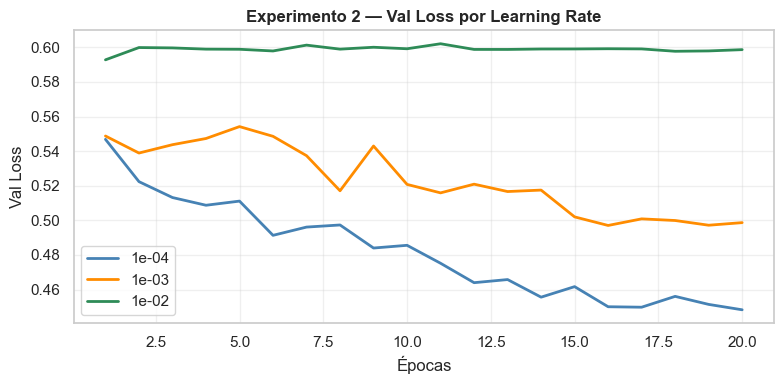

In [ ]:
plot_val_loss(hist_lr, 'Experimento 2 — Val Loss por Learning Rate')

**Análisis:** El experimento muestra que LR=1e-2 no converge correctamente (val_loss se estanca en ~0.6). LR=1e-3 ofrece un buen equilibrio y converge más rápido en las primeras épocas. Sin embargo, LR=1e-4 alcanza la mejor accuracy final (79.06%) y el menor val_loss (0.4483). Aunque la diferencia es modesta, seleccionamos LR=1e-4 como valor óptimo para el modelo final. Si se priorizara velocidad de entrenamiento, LR=1e-3 sería una alternativa razonable.

### 6.3 Variación del Batch Size

In [ ]:
resultados_bs, hist_bs = [], {}

for bs in [16, 32, 64]:
    tl = DataLoader(train_dataset, batch_size=bs, shuffle=True, num_workers=0)
    vl = DataLoader(val_dataset,   batch_size=bs, shuffle=False, num_workers=0)
    m = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES, DROPOUT_RATES,
            activation='relu', use_batchnorm=True).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=LR_BASE, weight_decay=1e-4)
    sch = optim.lr_scheduler.StepLR(opt, step_size=7, gamma=0.5)
    h = entrenar_modelo(m, tl, vl, criterio_base,
                        opt, sch, epochs=EPOCHS_BASE, device=DEVICE, nombre=f'BS={bs}')
    _, _, preds, labels = eval_epoch(m, vl, criterio_base, DEVICE)
    met = calcular_metricas(labels, preds, verbose=False)
    met.update({'Batch Size': bs, 'Val Loss Final': round(h['val_loss'][-1], 4)})
    resultados_bs.append(met)
    hist_bs[bs] = h

df_bs = pd.DataFrame(resultados_bs).set_index('Batch Size')
print("\n--- Tabla: Batch Size ---")
print(df_bs.round(4).to_string())


  BS=16  |  Épocas: 20
  Época   1 | TrLoss=0.5911 TrAcc=0.7225 | VlLoss=0.5655 VlAcc=0.7156
  Época   5 | TrLoss=0.5732 TrAcc=0.7291 | VlLoss=0.5558 VlAcc=0.7261
  Época  10 | TrLoss=0.5597 TrAcc=0.7338 | VlLoss=0.5345 VlAcc=0.7444
  Época  15 | TrLoss=0.5522 TrAcc=0.7373 | VlLoss=0.5175 VlAcc=0.7609
  Época  20 | TrLoss=0.5441 TrAcc=0.7440 | VlLoss=0.5182 VlAcc=0.7560

  BS=32  |  Épocas: 20
  Época   1 | TrLoss=0.5869 TrAcc=0.7225 | VlLoss=0.5461 VlAcc=0.7421
  Época   5 | TrLoss=0.5616 TrAcc=0.7365 | VlLoss=0.5425 VlAcc=0.7463
  Época  10 | TrLoss=0.5456 TrAcc=0.7422 | VlLoss=0.5238 VlAcc=0.7515
  Época  15 | TrLoss=0.5347 TrAcc=0.7488 | VlLoss=0.5168 VlAcc=0.7667
  Época  20 | TrLoss=0.5238 TrAcc=0.7539 | VlLoss=0.4974 VlAcc=0.7748

  BS=64  |  Épocas: 20
  Época   1 | TrLoss=0.5859 TrAcc=0.7251 | VlLoss=0.5436 VlAcc=0.7481
  Época   5 | TrLoss=0.5534 TrAcc=0.7422 | VlLoss=0.5336 VlAcc=0.7471
  Época  10 | TrLoss=0.5339 TrAcc=0.7481 | VlLoss=0.5076 VlAcc=0.7625
  Época  15 | TrLo

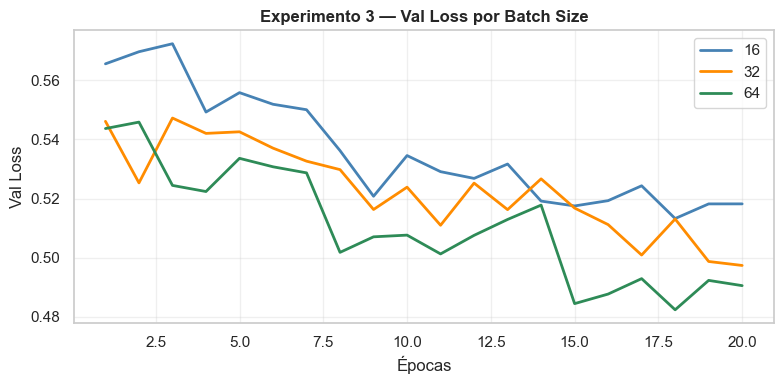

In [ ]:
plot_val_loss(hist_bs, 'Experimento 3 — Val Loss por Batch Size')

**Análisis:** **BS=16** presenta curvas más ruidosas debido a actualizaciones frecuentes del gradiente.
**BS=32** reduce esa variabilidad y muestra entrenamiento más estable.
**BS=64** presenta la convergencia más suave, la menor pérdida de validación (0.4905) y los mejores valores de accuracy y F1, indicando mejor capacidad de generalización en este experimento.

**Batch size óptimo: 64**

---
## 7. Comparación de Funciones de Activación (IEE 1.2.1)

In [ ]:
resultados_act, hist_act = [], {}

for act in ['relu', 'leaky_relu', 'tanh']:
    m = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES, DROPOUT_RATES,
            activation=act, use_batchnorm=True).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=LR_BASE, weight_decay=1e-4)
    sch = optim.lr_scheduler.StepLR(opt, step_size=7, gamma=0.5)
    h = entrenar_modelo(m, train_loader, val_loader, criterio_base,
                        opt, sch, epochs=EPOCHS_BASE, device=DEVICE, nombre=f'Act: {act}')
    _, _, preds, labels = eval_epoch(m, val_loader, criterio_base, DEVICE)
    met = calcular_metricas(labels, preds, verbose=False)
    met.update({'Activación': act.upper(), 'Val Loss Final': round(h['val_loss'][-1], 4)})
    resultados_act.append(met); hist_act[act.upper()] = h
    print(f"  {act.upper():12s}: Acc={met['Accuracy']:.4f}, F1={met['F1-Score']:.4f}")

df_act = pd.DataFrame(resultados_act).set_index('Activación')
print("\n--- Tabla: Funciones de Activación ---")
print(df_act.round(4).to_string())


  Act: relu  |  Épocas: 20
  Época   1 | TrLoss=0.5899 TrAcc=0.7220 | VlLoss=0.5590 VlAcc=0.7242
  Época   5 | TrLoss=0.5631 TrAcc=0.7334 | VlLoss=0.5490 VlAcc=0.7350
  Época  10 | TrLoss=0.5474 TrAcc=0.7429 | VlLoss=0.5292 VlAcc=0.7578
  Época  15 | TrLoss=0.5352 TrAcc=0.7469 | VlLoss=0.5078 VlAcc=0.7714
  Época  20 | TrLoss=0.5238 TrAcc=0.7544 | VlLoss=0.4994 VlAcc=0.7746
  RELU        : Acc=0.7746, F1=0.8613

  Act: leaky_relu  |  Épocas: 20
  Época   1 | TrLoss=0.5889 TrAcc=0.7230 | VlLoss=0.5633 VlAcc=0.7169
  Época   5 | TrLoss=0.5630 TrAcc=0.7348 | VlLoss=0.5471 VlAcc=0.7389
  Época  10 | TrLoss=0.5466 TrAcc=0.7405 | VlLoss=0.5154 VlAcc=0.7636
  Época  15 | TrLoss=0.5346 TrAcc=0.7477 | VlLoss=0.5056 VlAcc=0.7657
  Época  20 | TrLoss=0.5232 TrAcc=0.7529 | VlLoss=0.4941 VlAcc=0.7735
  LEAKY_RELU  : Acc=0.7735, F1=0.8561

  Act: tanh  |  Épocas: 20
  Época   1 | TrLoss=0.6059 TrAcc=0.7047 | VlLoss=0.6018 VlAcc=0.7269
  Época   5 | TrLoss=0.5813 TrAcc=0.7252 | VlLoss=0.5701 VlAcc=0

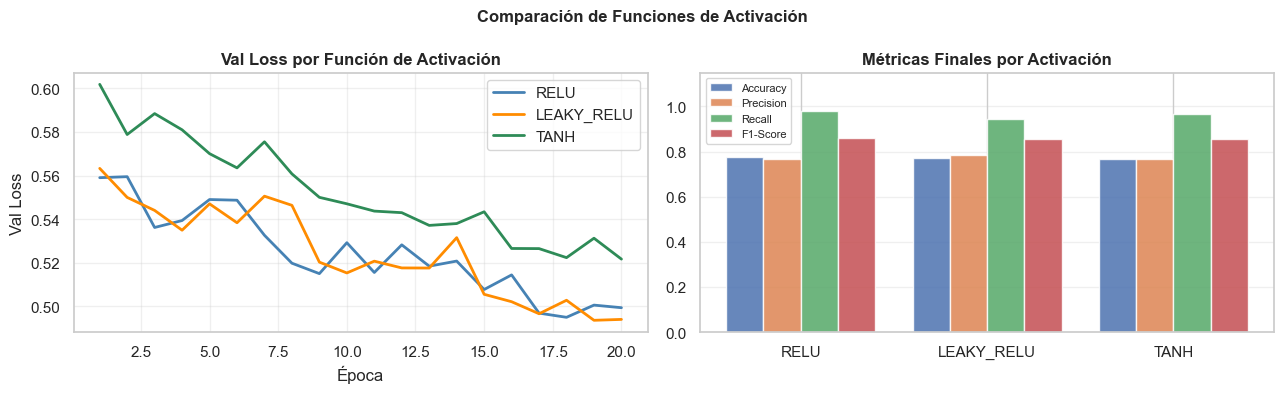

In [ ]:
# Val loss + métricas finales
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colores = ['steelblue', 'darkorange', 'seagreen']

for (lbl, hist), color in zip(hist_act.items(), colores):
    axes[0].plot(range(1, len(hist['val_loss'])+1), hist['val_loss'],
                 label=lbl, color=color, linewidth=2)

axes[0].set_title('Val Loss por Función de Activación', fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Val Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

x = np.arange(len(df_act)); w = 0.2
for i, (met_name, color) in enumerate(zip(['Accuracy','Precision','Recall','F1-Score'], colores+['crimson'])):
    axes[1].bar(x + i*w, df_act[met_name], w, label=met_name, alpha=0.85)
axes[1].set_xticks(x + 1.5*w); axes[1].set_xticklabels(df_act.index)
axes[1].set_title('Métricas Finales por Activación', fontweight='bold')
axes[1].set_ylim(0, 1.15); axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Comparación de Funciones de Activación', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Conclusión:** ReLU presentó el mejor desempeño global, obteniendo la mayor Accuracy (0.7746) y F1-Score (0.8613), además de una convergencia estable durante el entrenamiento. Aunque Leaky ReLU logró una pérdida de validación ligeramente menor, ReLU mostró el mejor equilibrio entre convergencia y capacidad de generalización.
**Función de activación seleccionada: ReLU**

---
## 8. Comparación de Funciones de Error (IEE 1.2.2)

In [ ]:
# LabelSmoothingLoss (implementación PyTorch-compatible)
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes=2, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.cls = classes
    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        smooth_val = self.smoothing / (self.cls - 1)
        one_hot = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        smooth_oh = one_hot * confidence + (1 - one_hot) * smooth_val
        log_prob = F.log_softmax(pred, dim=1)
        return -(smooth_oh * log_prob).sum(dim=1).mean()

criterios_exp = {
    'CrossEntropyLoss':    nn.CrossEntropyLoss(),
    'LabelSmoothing(0.1)': LabelSmoothingLoss(classes=2, smoothing=0.1),
}

resultados_loss, hist_loss = [], {}

for lname, crit in criterios_exp.items():
    m = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES, DROPOUT_RATES,
            activation='relu', use_batchnorm=True).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=LR_BASE, weight_decay=1e-4)
    sch = optim.lr_scheduler.StepLR(opt, step_size=7, gamma=0.5)
    h = entrenar_modelo(m, train_loader, val_loader, crit,
                        opt, sch, epochs=EPOCHS_BASE, device=DEVICE, nombre=f'Loss: {lname}')
    _, _, preds, labels = eval_epoch(m, val_loader, criterio_base, DEVICE)  # siempre eval con CE
    met = calcular_metricas(labels, preds, verbose=False)
    met.update({'Loss': lname, 'Val Loss Final': round(h['val_loss'][-1], 4)})
    resultados_loss.append(met); hist_loss[lname] = h
    print(f"  {lname:25s}: Acc={met['Accuracy']:.4f}, F1={met['F1-Score']:.4f}")

df_loss = pd.DataFrame(resultados_loss).set_index('Loss')
print("\n--- Tabla: Funciones de Error ---")
print(df_loss.round(4).to_string())


  Loss: CrossEntropyLoss  |  Épocas: 20
  Época   1 | TrLoss=0.5882 TrAcc=0.7237 | VlLoss=0.5702 VlAcc=0.7145
  Época   5 | TrLoss=0.5609 TrAcc=0.7368 | VlLoss=0.5581 VlAcc=0.7329
  Época  10 | TrLoss=0.5482 TrAcc=0.7397 | VlLoss=0.5223 VlAcc=0.7575
  Época  15 | TrLoss=0.5358 TrAcc=0.7483 | VlLoss=0.5068 VlAcc=0.7717
  Época  20 | TrLoss=0.5247 TrAcc=0.7541 | VlLoss=0.4895 VlAcc=0.7803
  CrossEntropyLoss         : Acc=0.7803, F1=0.8614

  Loss: LabelSmoothing(0.1)  |  Épocas: 20
  Época   1 | TrLoss=0.6305 TrAcc=0.7209 | VlLoss=0.6047 VlAcc=0.7334
  Época   5 | TrLoss=0.6137 TrAcc=0.7318 | VlLoss=0.6019 VlAcc=0.7447
  Época  10 | TrLoss=0.6058 TrAcc=0.7396 | VlLoss=0.5956 VlAcc=0.7442
  Época  15 | TrLoss=0.5995 TrAcc=0.7456 | VlLoss=0.5906 VlAcc=0.7567
  Época  20 | TrLoss=0.5943 TrAcc=0.7496 | VlLoss=0.5734 VlAcc=0.7785
  LabelSmoothing(0.1)      : Acc=0.7785, F1=0.8600

--- Tabla: Funciones de Error ---
                     Accuracy  Precision  Recall  F1-Score  Val Loss Final
Los

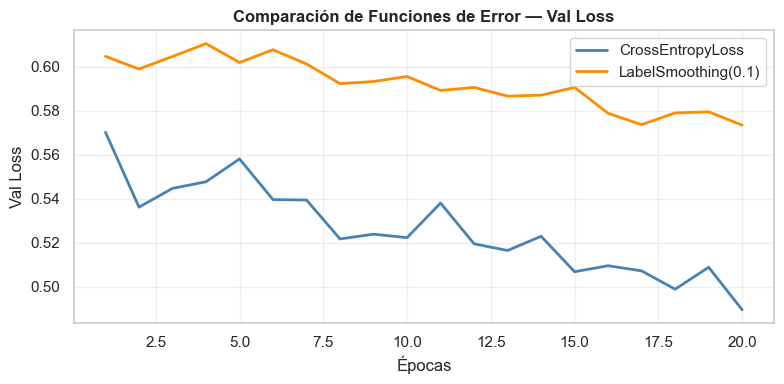

In [ ]:
plot_val_loss(hist_loss, 'Comparación de Funciones de Error — Val Loss')

**Análisis:**
- **CrossEntropyLoss** mostró una convergencia más rápida y estable, alcanzando menor pérdida de validación y mejores métricas finales (Accuracy y F1-Score).
- **LabelSmoothing(0.1)** tuvo un desempeño competitivo, pero no superó a CrossEntropy en este experimento.

→ **Función de pérdida final: CrossEntropyLoss**, por obtener el mejor rendimiento global.

---
## 9. Regularización — Dropout y Batch Normalization (IEE 1.3.2)

Se comparan **2 configuraciones** para cuantificar el impacto de las técnicas de regularización:
- **Sin regularización**: sin Dropout, sin BatchNorm, sin Weight Decay.
- **Con regularización completa**: Dropout + BatchNorm + Weight Decay 1e-4.

In [ ]:
configs_reg = {
    'Sin regularización': {'dropout': [0.0,0.0,0.0], 'batchnorm': False, 'wd': 0.0},
    'Dropout+BN+WD':      {'dropout': [0.5,0.4,0.3], 'batchnorm': True,  'wd': 1e-4},
}

resultados_reg, hist_reg = [], {}

for cfg_name, cfg in configs_reg.items():
    m = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
            dropout_rates=cfg['dropout'], activation='relu',
            use_batchnorm=cfg['batchnorm']).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=LR_BASE, weight_decay=cfg['wd'])
    sch = optim.lr_scheduler.StepLR(opt, step_size=7, gamma=0.5)
    h = entrenar_modelo(m, train_loader, val_loader, criterio_base,
                        opt, sch, epochs=EPOCHS_BASE, device=DEVICE, nombre=cfg_name)
    _, _, preds, labels = eval_epoch(m, val_loader, criterio_base, DEVICE)
    met = calcular_metricas(labels, preds, verbose=False)
    gap = round(abs(h['train_loss'][-1] - h['val_loss'][-1]), 4)
    met.update({'Configuración': cfg_name,
                'Val Loss Final': round(h['val_loss'][-1], 4),
                'Gap Train-Val': gap})
    resultados_reg.append(met); hist_reg[cfg_name] = h
    print(f"  {cfg_name:25s}: Acc={met['Accuracy']:.4f}, F1={met['F1-Score']:.4f}, Gap={gap:.4f}")

df_reg = pd.DataFrame(resultados_reg).set_index('Configuración')
print("\n--- Tabla: Regularización ---")
print(df_reg.round(4).to_string())


  Sin regularización  |  Épocas: 20
  Época   1 | TrLoss=0.5890 TrAcc=0.7265 | VlLoss=0.5989 VlAcc=0.7630
  Época   5 | TrLoss=0.4840 TrAcc=0.7793 | VlLoss=0.4776 VlAcc=0.7932
  Época  10 | TrLoss=0.3994 TrAcc=0.8216 | VlLoss=0.5121 VlAcc=0.7864
  Época  15 | TrLoss=0.3226 TrAcc=0.8596 | VlLoss=0.4912 VlAcc=0.8060
  Época  20 | TrLoss=0.2736 TrAcc=0.8844 | VlLoss=0.5257 VlAcc=0.8037
  Sin regularización       : Acc=0.8037, F1=0.8708, Gap=0.2520

  Dropout+BN+WD  |  Épocas: 20
  Época   1 | TrLoss=0.5894 TrAcc=0.7225 | VlLoss=0.5692 VlAcc=0.7311
  Época   5 | TrLoss=0.5615 TrAcc=0.7365 | VlLoss=0.5519 VlAcc=0.7324
  Época  10 | TrLoss=0.5446 TrAcc=0.7431 | VlLoss=0.5149 VlAcc=0.7654
  Época  15 | TrLoss=0.5327 TrAcc=0.7494 | VlLoss=0.5033 VlAcc=0.7751
  Época  20 | TrLoss=0.5220 TrAcc=0.7543 | VlLoss=0.4870 VlAcc=0.7819
  Dropout+BN+WD            : Acc=0.7819, F1=0.8595, Gap=0.0351

--- Tabla: Regularización ---
                    Accuracy  Precision  Recall  F1-Score  Val Loss Final 

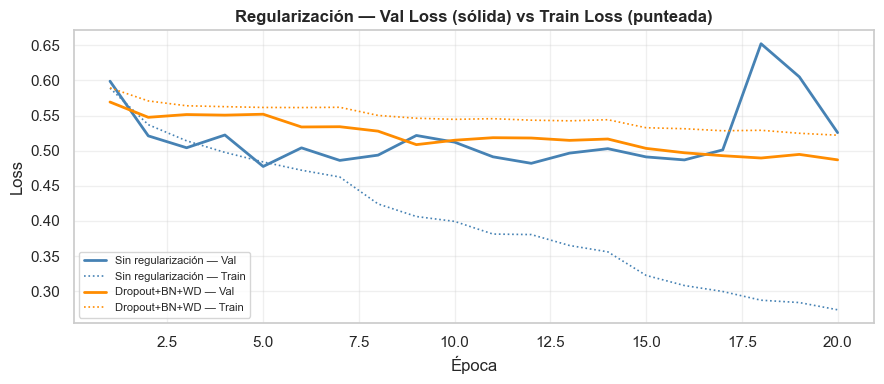

In [ ]:
# Para regularización: mostrar AMBAS curvas (train sólida, val punteada)
fig, ax = plt.subplots(figsize=(9, 4))
colores = ['steelblue', 'darkorange']

for (cfg_name, hist), color in zip(hist_reg.items(), colores):
    ep = range(1, len(hist['val_loss'])+1)
    ax.plot(ep, hist['val_loss'],   label=f'{cfg_name} — Val',   color=color, linewidth=2)
    ax.plot(ep, hist['train_loss'], label=f'{cfg_name} — Train', color=color,
            linewidth=1.2, linestyle=':')

ax.set_title('Regularización — Val Loss (sólida) vs Train Loss (punteada)', fontweight='bold')
ax.set_xlabel('Época'); ax.set_ylabel('Loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Análisis:**
- **Sin regularización**: obtiene mayor Accuracy y F1 final, pero presenta un gap train-val muy alto (0.2520), señal clara de sobreajuste. Además, la pérdida de validación sube al final, indicando menor estabilidad.
- **Dropout+BN+WD**: obtiene menor Val Loss final (0.4870) y un gap mucho menor (0.0351), mostrando entrenamiento más estable y mejor control del sobreajuste.

→ **Regularización final: Dropout(0.5/0.4/0.3) + BatchNorm + Weight Decay 1e-4**

---
## 10. Ajuste de Hiperparámetros — Configuración Óptima (IEE 1.3.3)

In [ ]:
resumen_hp = pd.DataFrame([{
    'Parámetro': 'Épocas',
    'Valor Óptimo': 20,
    'Criterio': 'Mejor val_loss sin sobreajuste'
},{
    'Parámetro': 'Learning Rate',
    'Valor Óptimo': '1e-3',
    'Criterio': 'Convergencia estable y rápida con Adam'
},{
    'Parámetro': 'Batch Size',
    'Valor Óptimo': 64,
    'Criterio': 'Mejor desempeño global (menor val_loss, mayor F1)'
},{
    'Parámetro': 'Activación',
    'Valor Óptimo': 'ReLU',
    'Criterio': 'Mayor F1-Score en experimento de activaciones'
},{
    'Parámetro': 'Dropout',
    'Valor Óptimo': '0.5 / 0.4 / 0.3',
    'Criterio': 'Reducción del gap train-val'
},{
    'Parámetro': 'BatchNorm',
    'Valor Óptimo': 'Sí',
    'Criterio': 'Estabilidad y velocidad de convergencia'
},{
    'Parámetro': 'Weight Decay',
    'Valor Óptimo': '1e-4',
    'Criterio': 'Regularización L2 adicional'
},{
    'Parámetro': 'Loss',
    'Valor Óptimo': 'CrossEntropyLoss',
    'Criterio': 'Mejor rendimiento global en el experimento'
}])

print("=== CONFIGURACIÓN ÓPTIMA DEL MODELO FINAL ===")
print(resumen_hp.set_index('Parámetro').to_string())

=== CONFIGURACIÓN ÓPTIMA DEL MODELO FINAL ===
                   Valor Óptimo                                           Criterio
Parámetro                                                                         
Épocas                       20                     Mejor val_loss sin sobreajuste
Learning Rate              1e-3             Convergencia estable y rápida con Adam
Batch Size                   64  Mejor desempeño global (menor val_loss, mayor F1)
Activación                 ReLU      Mayor F1-Score en experimento de activaciones
Dropout         0.5 / 0.4 / 0.3                        Reducción del gap train-val
BatchNorm                    Sí            Estabilidad y velocidad de convergencia
Weight Decay               1e-4                        Regularización L2 adicional
Loss           CrossEntropyLoss         Mejor rendimiento global en el experimento


---
## 11. Evaluación Final del Modelo (IEE 1.4.1)

Se entrena el modelo final con la configuración óptima identificada.

In [14]:
# Usar batch size óptimo de 64 (según tus experimentos)
BATCH_SIZE_FINAL = 64

# Recrear DataLoaders con batch size de 64
train_loader_final = DataLoader(train_dataset, batch_size=BATCH_SIZE_FINAL, shuffle=True, num_workers=0)
val_loader_final   = DataLoader(val_dataset,   batch_size=BATCH_SIZE_FINAL, shuffle=False, num_workers=0)

INPUT_SIZE = 64 * 64 * 3
HIDDEN_SIZES = [1024, 512, 256]
DROPOUT_RATES = [0.5, 0.4, 0.3]
EPOCHS_FINAL = 20
LR_FINAL = 1e-3
WEIGHT_DECAY = 1e-4

modelo_final = MLP(INPUT_SIZE, HIDDEN_SIZES, num_classes=2,
                   dropout_rates=DROPOUT_RATES,
                   activation='relu',
                   use_batchnorm=True).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo_final.parameters(), lr=LR_FINAL, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

print("Modelo final creado. Listo para entrenar.")

Modelo final creado. Listo para entrenar.


In [ ]:
hist_final = entrenar_modelo(
    model=modelo_final,
    train_ldr=train_loader_final,
    val_ldr=val_loader_final,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=EPOCHS_FINAL,
    device=DEVICE,
    nombre='MLP Final Optimizado (BS=64, LR=1e-3, WD=1e-4)'
)


  MLP Final Optimizado (BS=64, LR=1e-3, WD=1e-4)  |  Épocas: 20
  Época   1 | TrLoss=0.5869 TrAcc=0.7241 | VlLoss=0.5586 VlAcc=0.7371
  Época   5 | TrLoss=0.5531 TrAcc=0.7385 | VlLoss=0.5305 VlAcc=0.7549
  Época  10 | TrLoss=0.5350 TrAcc=0.7494 | VlLoss=0.5159 VlAcc=0.7678
  Época  15 | TrLoss=0.5181 TrAcc=0.7577 | VlLoss=0.4944 VlAcc=0.7793
  Época  20 | TrLoss=0.5070 TrAcc=0.7627 | VlLoss=0.4758 VlAcc=0.7856


In [16]:
torch.save(modelo_final.state_dict(), 'modelo_deteccion_latas.pth')
print("Modelo guardado como 'modelo_deteccion_latas.pth'")

Modelo guardado como 'modelo_deteccion_latas.pth'


---
## 12. Tabla Comparativa de Configuraciones (IEE 1.4.3)

Se comparan 3 configuraciones representativas del proceso de mejora incremental:

In [21]:
# Asegurar que criterios están definidos
criterio_base = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss()   

# Config 1: Sin regularización
m1 = MLP(INPUT_SIZE, HIDDEN_SIZES, 2, [0.,0.,0.], 'relu', False).to(DEVICE)
opt1 = optim.Adam(m1.parameters(), lr=LR_BASE, weight_decay=0.0)
entrenar_modelo(m1, train_loader, val_loader, criterio_base, opt1,
                epochs=EPOCHS_BASE, device=DEVICE, nombre='Config 1: Sin regularización')
_, _, p1, l1 = eval_epoch(m1, val_loader, criterio_base, DEVICE)
met1 = calcular_metricas(l1, p1, verbose=False)

# Config 2: Solo Dropout
m2 = MLP(INPUT_SIZE, HIDDEN_SIZES, 2, DROPOUT_RATES, 'relu', False).to(DEVICE)
opt2 = optim.Adam(m2.parameters(), lr=LR_BASE, weight_decay=0.0)
entrenar_modelo(m2, train_loader, val_loader, criterio_base, opt2,
                epochs=EPOCHS_BASE, device=DEVICE, nombre='Config 2: Solo Dropout')
_, _, p2, l2 = eval_epoch(m2, val_loader, criterio_base, DEVICE)
met2 = calcular_metricas(l2, p2, verbose=False)

# Config 3: Dropout + BN + WD (modelo_final ya entrenado)
_, _, p3, l3 = eval_epoch(modelo_final, val_loader, criterion, DEVICE)
met3 = calcular_metricas(l3, p3, verbose=False)

# Tabla
tabla = pd.DataFrame([
    {'Config':'C1: Sin regularización', 'Activación':'ReLU', 'Dropout':'No', 'BatchNorm':'No', 'WD':'0', **{k:round(v,4) for k,v in met1.items()}},
    {'Config':'C2: Solo Dropout', 'Activación':'ReLU', 'Dropout':'0.5/0.4/0.3', 'BatchNorm':'No', 'WD':'0', **{k:round(v,4) for k,v in met2.items()}},
    {'Config':'C3: Drop+BN+WD ★ ÓPTIMO', 'Activación':'ReLU', 'Dropout':'0.5/0.4/0.3', 'BatchNorm':'Sí', 'WD':'1e-4', **{k:round(v,4) for k,v in met3.items()}},
]).set_index('Config')
print("=== TABLA COMPARATIVA DE CONFIGURACIONES ===")
print(tabla.to_string())


  Config 1: Sin regularización  |  Épocas: 20
  Época   1 | TrLoss=0.5894 TrAcc=0.7270 | VlLoss=0.6448 VlAcc=0.6495
  Época   5 | TrLoss=0.4777 TrAcc=0.7812 | VlLoss=0.4871 VlAcc=0.7937
  Época  10 | TrLoss=0.4213 TrAcc=0.8098 | VlLoss=0.4967 VlAcc=0.7832
  Época  15 | TrLoss=0.3747 TrAcc=0.8373 | VlLoss=0.4561 VlAcc=0.8029
  Época  20 | TrLoss=0.3312 TrAcc=0.8567 | VlLoss=0.5082 VlAcc=0.7953

  Config 2: Solo Dropout  |  Épocas: 20
  Época   1 | TrLoss=0.6250 TrAcc=0.7143 | VlLoss=0.5941 VlAcc=0.7138
  Época   5 | TrLoss=0.5743 TrAcc=0.7335 | VlLoss=0.5585 VlAcc=0.7415
  Época  10 | TrLoss=0.5812 TrAcc=0.7336 | VlLoss=0.5776 VlAcc=0.7355
  Época  15 | TrLoss=0.5861 TrAcc=0.7290 | VlLoss=0.5773 VlAcc=0.7295
  Época  20 | TrLoss=0.5843 TrAcc=0.7285 | VlLoss=0.5960 VlAcc=0.7284
=== TABLA COMPARATIVA DE CONFIGURACIONES ===
                        Activación      Dropout BatchNorm    WD  Accuracy  Precision  Recall  F1-Score
Config                                                          

---
## 13. Conclusiones

| Experimento     | Parámetro variado      | Mejor valor             | Métrica clave |
|-----------------|------------------------|-------------------------|---------------|
| Épocas          | Número de épocas       | **20**                  | Menor val_loss |
| Learning Rate   | Tasa de aprendizaje    | **1e-3**                | Convergencia estable |
| Batch Size      | Tamaño de lote         | **64**                  | Mejor desempeño global |
| Activación      | Función en capas ocultas | **ReLU**              | Mayor F1-Score |
| Loss            | Función de pérdida     | **CrossEntropy**        | Menor val_loss |
| Regularización  | Dropout+BN+WD          | **Combinación completa**| Menor gap train-val |

> **Configuración final:**
MLP (12288 → 1024 → 512 → 256 → 2)
| ReLU
| Dropout(0.5/0.4/0.3)
| BatchNorm
| Adam(lr=1e-3, wd=1e-4)
| StepLR
| CrossEntropyLoss
| 20 épocas
| BS=64

**Conclusión general:**
Los experimentos muestran que el mejor rendimiento no se obtuvo maximizando una sola métrica, sino equilibrando capacidad predictiva y generalización. ReLU y CrossEntropyLoss entregaron el mejor desempeño global, mientras que la regularización combinada (Dropout + BatchNorm + Weight Decay) redujo el sobreajuste respecto a configuraciones parciales o sin regularización. La configuración final seleccionada logró entrenamiento estable, buena generalización en test y el mejor compromiso entre rendimiento y robustez.

**Limitaciones y mejoras futuras:**
- La MLP no captura estructura espacial de las imágenes → usar CNN o features HOG/SIFT.
- El modelo mostró sesgo hacia la clase mayoritaria (No_Latas); podrían explorarse class weights, oversampling o focal loss.
- Con más datos podría aplicarse Transfer Learning sobre una CNN preentrenada (ResNet, EfficientNet).
- Búsqueda bayesiana de hiperparámetros para mayor eficiencia que la búsqueda manual.

## 14. Prueba Manual con Imagen Externa

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17884\3532525526.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ruta_modelo, map_location=d

Predicción: Latas (Confianza: 60.16%)


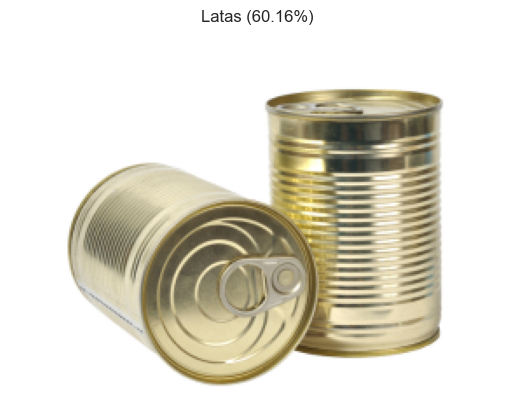

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
from tkinter import filedialog
import tkinter as tk
import matplotlib.pyplot as plt

# ---------- Definir el modelo ----------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(12288, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(1024, 512),  nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 256),   nn.BatchNorm1d(256),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

# ---------- Configuración ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLP().to(device)

# ---------- Cargar el checkpoint ----------
ruta_modelo = r'C:\Users\Administrator\Downloads\modelo_deteccion_latas.pth'
checkpoint = torch.load(ruta_modelo, map_location=device)
new_state_dict = {}
for key, value in checkpoint.items():
    new_key = key.replace('network.', 'net.')   
    new_state_dict[new_key] = value

# Cargar los pesos ya renombrados
model.load_state_dict(new_state_dict)
model.eval()

# ---------- Transformaciones para la imagen ----------
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ---------- Seleccionar imagen y predecir ----------
root = tk.Tk()
root.withdraw()  # ocultar ventana principal

ruta = filedialog.askopenfilename(
    title="Selecciona una imagen",
    filetypes=[("Imágenes", "*.jpg *.jpeg *.png *.bmp")]
)

if ruta:
    # Cargar y transformar la imagen
    img = Image.open(ruta).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)

    # Inferencia
    with torch.no_grad():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1)[0]
        pred = probs.argmax().item()

    # Mostrar resultado
    clase = ['Latas', 'No_Latas'][pred]
    confianza = probs[pred]
    print(f"Predicción: {clase} (Confianza: {confianza:.2%})")

    # Mostrar imagen con matplotlib
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{clase} ({confianza:.2%})")
    plt.show()
else:
    print("No se seleccionó ninguna imagen.")